In [5]:
import matplotlib.pyplot as plt
import numpy as np

from superfv import (
    HydroSolver,
    ics,
    TimeIntegrator,
    RiemannSolver,
    FluxRecipe,
    MUSCL_SlopeLimiter,
    BC,
)
from teyssier.muscl import cons_to_prim, muscl

In [6]:
N = 100

sim = HydroSolver(
    ic=ics.sod_shock_tube_1d,
    bcx=(BC.FREE, BC.FREE),
    nx=N,
    p=1,
    flux_recipe=FluxRecipe.PRIM_PRIM_LIM,
    riemann_solver=RiemannSolver.HLLC_TEYSSIER,
    use_MUSCL=True,
    MUSCL_limiter=MUSCL_SlopeLimiter.MONCEN,
)
sim.run(t=0.245, time_integrator=TimeIntegrator.MUSCL_HANCOCK, allow_overshoot=True)

ut = muscl(
    0.245,
    N,
    ic_type="sod test",
    bc_type="free",
    riemann_solver="hllc",
    slp_type="moncen2",
)
x = (np.arange(ut.shape[2]) + 0.5) / ut.shape[2]
wt = cons_to_prim(ut[-1, :, :])

SuperFV: 68 steps | [t=2.47e-01/2.45e-01] | rho_min=1.25e-01 | E_cons=2.84e-14 | wall=2.54e-02s (done)
cell= 100  itermax= 100000
Done  67 0.24701220468899104


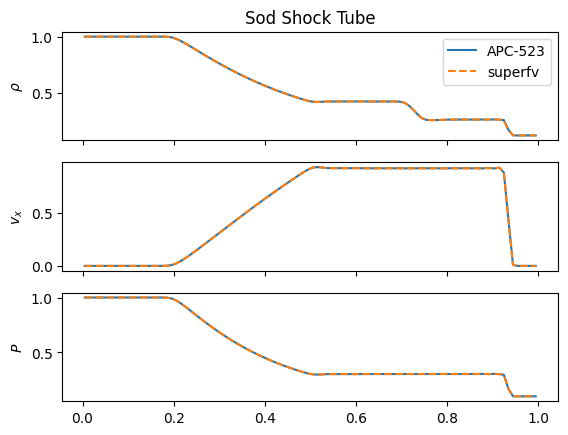

In [7]:
idx = sim.params.variable_index_map
fig, axs = plt.subplots(3, 1, sharex=True)

axs[0].set_title("Sod Shock Tube")

axs[0].set_ylabel(r"$\rho$")
axs[1].set_ylabel(r"$v_x$")
axs[2].set_ylabel(r"$P$")

axs[0].plot(x, wt[0, :], label="APC-523")
axs[0].plot(
    sim.mesh.x_centers,
    sim.snapshot_history[-1].w[idx("rho"), :, 0, 0],
    label="superfv",
    linestyle="--",
)
axs[0].legend()

axs[1].plot(x, wt[1, :], label="APC-523")
axs[1].plot(
    sim.mesh.x_centers,
    sim.snapshot_history[-1].w[idx("vx"), :, 0, 0],
    label="superfv",
    linestyle="--",
)

axs[2].plot(x, wt[2, :], label="APC-523")
axs[2].plot(
    sim.mesh.x_centers,
    sim.snapshot_history[-1].w[idx("P"), :, 0, 0],
    label="superfv",
    linestyle="--",
)